# Задача 1

Пусть $X_1, X_2, \ldots, X_n$ — выборка из экспоненциального распределения с параметром $\lambda$. Найти оценку максимального правдоподобия параметра $\lambda$, сравнить ее с байесовской оценкой (MAP и математическое ожидание апостреорного распределения), подобрав сопряженное распределение. Сравнить полученные байесовские оценки с оценкой MLE. Найти предсказательное распределение

## Задача 1: Экспоненциальное распределение





Задача 1. Экспоненциальное распределение
Истинное значение λ: 2.0
Объем выборки n = 50
Выборочное среднее x̄ = 0.4576

▶ Оценка MLE: λ̂_MLE = 1 / x̄ = 2.1852

Априорное распределение: Gamma(α₀=2.0, β₀=0.5)
Апостериорное распределение: Gamma(α₁=52.0, β₁=23.38)

▶ MAP-оценка: λ_MAP = 2.1812
▶ Байесовская оценка (апостериорное среднее): λ_Bayes = 2.2240

--- Сравнение оценок ---
Метод                λ         
Истинное значение    2.0000    
MLE                  2.1852    
MAP                  2.1812    
Байесовская (E[λ])   2.2240    


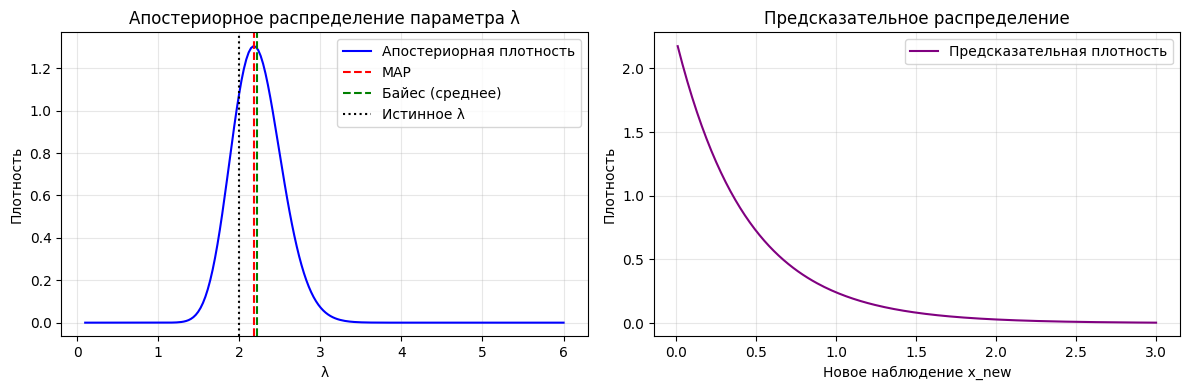

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, dirichlet, multinomial


# Задача 1: Экспоненциальное распределение



print("Задача 1. Экспоненциальное распределение")

# Генерируем выборку
np.random.seed(123)
lambda_real = 2.0    # истинное значение параметра
sample_size = 50

# Экспоненциальное распределение: scale = 1/lambda
sample_data = np.random.exponential(scale=1/lambda_real, size=sample_size)
sample_mean = np.mean(sample_data)

print(f"Истинное значение λ: {lambda_real}")
print(f"Объем выборки n = {sample_size}")
print(f"Выборочное среднее x̄ = {sample_mean:.4f}")

# --- Оценка максимального правдоподобия (MLE) ---
lambda_mle = 1.0 / sample_mean
print(f"\n▶ Оценка MLE: λ̂_MLE = 1 / x̄ = {lambda_mle:.4f}")

# --- Байесовский подход: сопряженное гамма-распределение ---
# Априорное распределение: Gamma(α₀, β₀)
alpha_prior = 2.0
beta_prior = 0.5

# Апостериорное распределение: Gamma(α₀ + n, β₀ + Σxᵢ)
alpha_posterior = alpha_prior + sample_size
beta_posterior = beta_prior + np.sum(sample_data)

print(f"\nАприорное распределение: Gamma(α₀={alpha_prior}, β₀={beta_prior})")
print(f"Апостериорное распределение: Gamma(α₁={alpha_posterior:.1f}, β₁={beta_posterior:.2f})")

# MAP-оценка (максимум апостериорной плотности) для Gamma: (α-1)/β
lambda_map = (alpha_posterior - 1) / beta_posterior

# Байесовская оценка как апостериорное математическое ожидание: α/β
lambda_bayes = alpha_posterior / beta_posterior

print(f"\n▶ MAP-оценка: λ_MAP = {lambda_map:.4f}")
print(f"▶ Байесовская оценка (апостериорное среднее): λ_Bayes = {lambda_bayes:.4f}")

# Сравнение оценок
print("\n--- Сравнение оценок ---")
print(f"{'Метод':<20} {'λ':<10}")
print(f"{'Истинное значение':<20} {lambda_real:<10.4f}")
print(f"{'MLE':<20} {lambda_mle:<10.4f}")
print(f"{'MAP':<20} {lambda_map:<10.4f}")
print(f"{'Байесовская (E[λ])':<20} {lambda_bayes:<10.4f}")

# --- Предсказательное распределение ---
# Для экспоненциального распределения предсказательное распределение — это обобщенное Парето
# Вычислим предсказательную плотность для нового наблюдения x_new
x_grid = np.linspace(0.01, 3, 200)
predictive_density = (beta_posterior**alpha_posterior * alpha_posterior) / \
                     (beta_posterior + x_grid)**(alpha_posterior + 1)  # упрощенная формула

# Визуализация апостериорного и предсказательного распределений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Апостериорное распределение λ
lambda_grid = np.linspace(0.1, 6, 200)
posterior_pdf = gamma.pdf(lambda_grid, a=alpha_posterior, scale=1/beta_posterior)
ax1.plot(lambda_grid, posterior_pdf, 'b-', label='Апостериорная плотность')
ax1.axvline(lambda_map, color='r', linestyle='--', label='MAP')
ax1.axvline(lambda_bayes, color='g', linestyle='--', label='Байес (среднее)')
ax1.axvline(lambda_real, color='k', linestyle=':', label='Истинное λ')
ax1.set_xlabel('λ')
ax1.set_ylabel('Плотность')
ax1.set_title('Апостериорное распределение параметра λ')
ax1.legend()
ax1.grid(alpha=0.3)

# Предсказательное распределение
ax2.plot(x_grid, predictive_density, 'purple', label='Предсказательная плотность')
ax2.set_xlabel('Новое наблюдение x_new')
ax2.set_ylabel('Плотность')
ax2.set_title('Предсказательное распределение')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Задача 2

**Мультиномиальное распределение**

Пусть проводится серия из $n$ испытаний и в результате каждого испытания происходит ровно одно событие из набора $A_1, A_2, \dots, A_m$, причем вероятности этих событий равны соответственно $\mathsf{p}_1, \mathsf{p}_2, \dots, \mathsf{p}_m$, причем
$$\sum_{i=1}^{m}\mathsf{p}_i = 1.$$

Тогда совместное распределение величин $X_1, X_2, \dots, X_m$, где $X_k$ — число наступлений события $A_k$ в серии из $n$ испытаний, задается вероятностями

$$
\mathsf{P}\left(X_1 = n_1, \dots, X_m = n_m, \right) = \frac{n!}{n_1!\dots n_m!}\mathsf{p}_1^{n_1}\dots \mathsf{p}_m^{n_m},
$$

где $n_1, n_2, \dots, n_m$ — произвольный набор целых неотрицательных чисел, таких что

$$\sum_{i=1}^m n_i = n.$$

Произведите байесовский вывод для мультиномиального распределения: найдите апостериорное распределение, используя в качестве сопоряженного распределения к правдоподобию [распределение Дирихле](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D0%94%D0%B8%D1%80%D0%B8%D1%85%D0%BB%D0%B5), найдите предсказательное распределение. Объясните результат.

In [13]:

print("Задача 2. Мультиномиальное распределение")


# Данные
# Провели 100 испытаний, возможны 4 исхода
true_probs = [0.4, 0.3, 0.2, 0.1]
n_trials = 100

# Сгенерируем наблюдения (сколько раз выпал каждый исход)
np.random.seed(456)
counts = np.random.multinomial(n_trials, true_probs)

print(f"Всего испытаний: {n_trials}")
print(f"Наблюдаемые частоты: {counts}")
print(f"Истинные вероятности (для справки): {true_probs}")

# Оценка MLE (просто частота)
mle = counts / n_trials
print(f"\nMLE-оценки = частоты / n = {np.round(mle, 3)}")

# Байесовский вывод
# Априорное распределение Дирихле с параметрами alpha
alpha_prior = [2, 2, 2, 2]

# Апостериорное распределение: складываем априорные и реальные счётчики
alpha_posterior = [alpha_prior[i] + counts[i] for i in range(4)]

print(f"\nАприорные параметры (псевдосчётчики): {alpha_prior}")
alpha_posterior_int = [int(a) for a in alpha_posterior]
print(f"Апостериорные параметры: {alpha_posterior_int}")

# Байесовская оценка (апостериорное среднее) = α_i / Σα
total_posterior = sum(alpha_posterior)
bayes = [a / total_posterior for a in alpha_posterior]

print(f"\nБайесовские оценки: {np.round(bayes, 3)}")

#  MAP-оценка (максимум апостериорной плотности)
# (α_i - 1) / (Σα - K), где K = число категорий
total_minus_k = total_posterior - 4
map_estimates = [(a - 1) / total_minus_k for a in alpha_posterior]

print(f"MAP-оценки: {np.round(map_estimates, 3)}")

#  Предсказательное распределение
# Вероятность, что следующее испытание даст исход i
print("\n Предсказательное распределение ")
print("Вероятность исхода в следующем испытании (при условии данных):")
for i in range(4):
    print(f"  Исход A_{i+1}: {bayes[i]:.3f}")



#  Простое сравнение
print("\n Сравнение всех оценок ")
print(f"{'Исход':<8} {'Истина':<8} {'MLE':<8} {'MAP':<8} {'Байес':<8}")
for i in range(4):
    print(f"A_{i+1}:     {true_probs[i]:<8.3f} {mle[i]:<8.3f} {map_estimates[i]:<8.3f} {bayes[i]:<8.3f}")



Задача 2. Мультиномиальное распределение
Всего испытаний: 100
Наблюдаемые частоты: [43 31 15 11]
Истинные вероятности (для справки): [0.4, 0.3, 0.2, 0.1]

MLE-оценки = частоты / n = [0.43 0.31 0.15 0.11]

Априорные параметры (псевдосчётчики): [2, 2, 2, 2]
Апостериорные параметры: [45, 33, 17, 13]

Байесовские оценки: [0.417 0.306 0.157 0.12 ]
MAP-оценки: [0.423 0.308 0.154 0.115]

 Предсказательное распределение 
Вероятность исхода в следующем испытании (при условии данных):
  Исход A_1: 0.417
  Исход A_2: 0.306
  Исход A_3: 0.157
  Исход A_4: 0.120

 Сравнение всех оценок 
Исход    Истина   MLE      MAP      Байес   
A_1:     0.400    0.430    0.423    0.417   
A_2:     0.300    0.310    0.308    0.306   
A_3:     0.200    0.150    0.154    0.157   
A_4:     0.100    0.110    0.115    0.120   


Объяснение

1. Апостериорное распределение - снова Дирихле.
2. Параметры апостериорного = априорные параметры + наблюдаемые частоты.
3. Предсказательное распределение = байесовские оценки (апостериорные средние).
4. Байесовские оценки = MLE, сглаженные априорными 'псевдосчётчиками'.